# Gridded COARDS NetCDF files

COARDS-convention rectilinear grids (packed int16 with scale/offset). Same workflow as the CF notebook: inspect, plot, retrieve, reduce, mutate, crop, save.

In [1]:
%matplotlib inline
from pathlib import Path
import tempfile

import numpy as np
import geopandas as gpd
from shapely.geometry import box

from pyramids.netcdf import NetCDF, UgridDataset
from pyramids.feature import FeatureCollection

DATA = Path('../../../../examples/data/netcdf/samples')

2026-06-18 02:08:36 | INFO | pyramids.base.config | Logging is configured.


## `coards__4v__1d3-3d1.nc`

NCEP reanalysis air temperature on a 2.5° global grid (packed int16).

**Open the file and inspect the container**

In [2]:
nc = NetCDF.read_file(DATA / 'coards__4v__1d3-3d1.nc')
nc

Driver: netCDF/Network Common Data Format
Files: ..\..\..\..\examples\data\netcdf\samples\coards__4v__1d3-3d1.nc
Size is 512, 512
Corner Coordinates:
Upper Left  (    0.0,    0.0)
Lower Left  (    0.0,  512.0)
Upper Right (  512.0,    0.0)
Lower Right (  512.0,  512.0)
Center      (  256.0,  256.0)

**Dimensions and variables**

In [3]:
# get_all_metadata() returns a NetCDFMetadata whose summary lists dimensions and, for each
# variable, its dims / shape / dtype / unit / scale-offset.
meta = nc.get_all_metadata()
print(meta)

NetCDFMetadata
  Driver: netCDF
  Root group: /
  Dimensions (3):
    lat                  size=25
    lon                  size=53
    time                 size=100
  Variables (4):
    air dims=('/time', '/lat', '/lon') shape=(100, 25, 53) dtype=int16 unit='degK' scale=0.01 offset=None
    lat dims=('/lat',) shape=(25,) dtype=float32 unit='degrees_north'
    lon dims=('/lon',) shape=(53,) dtype=float32 unit='degrees_east'
    time dims=('/time',) shape=(100,) dtype=float32 unit='hours since 1800-01-01'
  Global attributes: Conventions, title, description, platform, references


**Global attributes**

In [4]:
nc.global_attributes

{'Conventions': 'COARDS',
 'title': '4x daily NMC reanalysis (1948)',
 'description': 'Data is from NMC initialized reanalysis\n(4x/day).  These are the 0.9950 sigma level values.',
 'platform': 'Model',
 'references': 'http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanalysis.html'}

**Plot the variable** (a 2-D slice is auto-selected for >2-D variables)

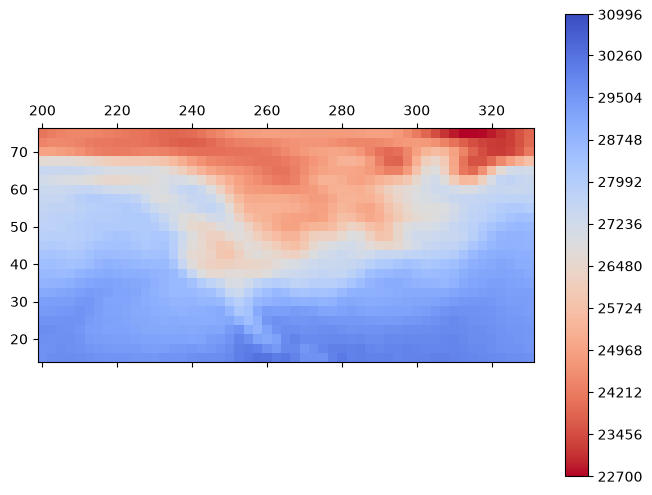

In [5]:
nc.plot(variable='air')

**Retrieve the underlying data**

In [6]:
var = nc.get_variable('air')
data = var.read_array()
print('shape:', data.shape)
print('min / mean / max:', float(np.nanmin(data)), float(np.nanmean(data)), float(np.nanmax(data)))

shape: (100, 25, 53)
min / mean / max: 22700.0 27317.780233962265 30450.0


**Reduce a dimension** — collapse the time axis to its mean

In [7]:
time_mean = nc.reduce('time', how='mean')
print('dimensions after reducing time:', dict(time_mean.dimension_sizes))

dimensions after reducing time: {'x': 53, 'y': 25}


**Add a variable** — derive a 2-D field and append it as a new variable

In [8]:
work = Path(tempfile.mkdtemp())
slice2d = data[tuple(0 for _ in range(data.ndim - 2))]
NetCDF.create_from_array(
    arr=slice2d, geo=var.geotransform, epsg=var.epsg or 4326,
    variable_name='air_slice0', path=str(work / 'derived.nc'),
)
nc.add_variable(NetCDF.read_file(str(work / 'derived.nc')), 'air_slice0')
print('variables after add:', nc.variable_names)

variables after add: ['air', 'air_slice0']


**Remove a variable**

In [9]:
nc.remove_variable('air_slice0')
print('variables after remove:', nc.variable_names)

variables after remove: ['air']


**Crop every variable with one polygon** — `crop` clips the whole container in a single call and returns a new `NetCDF`

2026-06-18 02:08:38 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


cropped dimensions: {'time': 100, 'x': 53, 'y': 25}


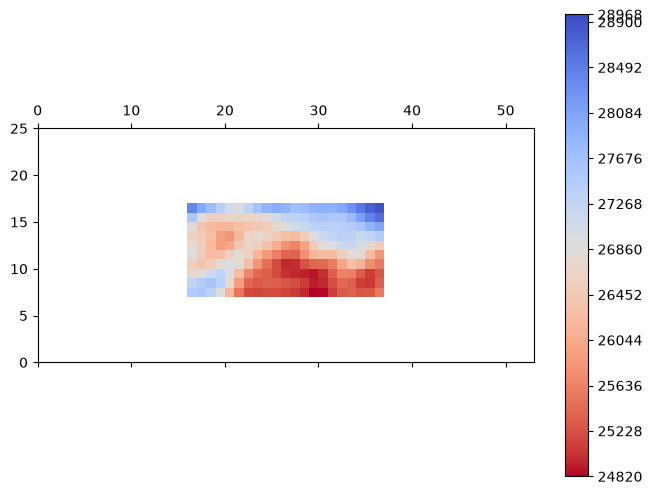

In [10]:
xmin, ymin, xmax, ymax = var.total_bounds
polygon = gpd.GeoDataFrame(
    geometry=[box(xmin + (xmax - xmin) * 0.3, ymin + (ymax - ymin) * 0.3,
                  xmin + (xmax - xmin) * 0.7, ymin + (ymax - ymin) * 0.7)],
    crs=var.epsg or 4326,
)
cropped = nc.crop(FeatureCollection(polygon))
print('cropped dimensions:', dict(cropped.dimension_sizes))
cropped.plot(variable='air')

**Save the result to a new NetCDF file**

In [11]:
out = work / 'cropped.nc'
cropped.to_file(str(out))
print('saved cropped container to', out.name, '->', out.exists())

saved cropped container to cropped.nc -> True


## `coards__5v__1d4-4d1.nc`

Relative humidity with a vertical level dimension (4-D, packed int16). Longitudes run 0–360.

**Open the file and inspect the container**

In [12]:
nc = NetCDF.read_file(DATA / 'coards__5v__1d4-4d1.nc')
nc

Driver: netCDF/Network Common Data Format
Files: ..\..\..\..\examples\data\netcdf\samples\coards__5v__1d4-4d1.nc
Size is 512, 512
Corner Coordinates:
Upper Left  (    0.0,    0.0)
Lower Left  (    0.0,  512.0)
Upper Right (  512.0,    0.0)
Lower Right (  512.0,  512.0)
Center      (  256.0,  256.0)

**Dimensions and variables**

In [13]:
# get_all_metadata() returns a NetCDFMetadata whose summary lists dimensions and, for each
# variable, its dims / shape / dtype / unit / scale-offset.
meta = nc.get_all_metadata()
print(meta)

NetCDFMetadata
  Driver: netCDF
  Root group: /
  Dimensions (4):
    lat                  size=37
    level                size=4
    lon                  size=72
    time                 size=12
  Variables (5):
    lat dims=('/lat',) shape=(37,) dtype=float32 unit='degrees_north'
    level dims=('/level',) shape=(4,) dtype=float32 unit='millibar'
    lon dims=('/lon',) shape=(72,) dtype=float32 unit='degrees_east'
    rhum dims=('/time', '/level', '/lat', '/lon') shape=(12, 4, 37, 72) dtype=int16 unit='%' scale=0.009999999776482582 offset=302.6600036621094
    time dims=('/time',) shape=(12,) dtype=float64 unit='hours since 1-1-1 00:00:0.0'
  Global attributes: Conventions, title, base_date, history, description, ... (6 total)


**Global attributes**

In [14]:
nc.global_attributes

{'Conventions': 'COARDS',
 'title': 'mean daily NMC reanalysis (2003)',
 'base_date': (2003, 1, 1),
 'history': 'created 03/08/18 by Hoop (netCDF2.3)',
 'description': 'Data is from NMC initialized reanalysis\n(4x/day).  It consists of most variables interpolated to\npressure surfaces from model (sigma) surfaces.',
 'platform': 'Model'}

**Plot the variable** (a 2-D slice is auto-selected for >2-D variables)

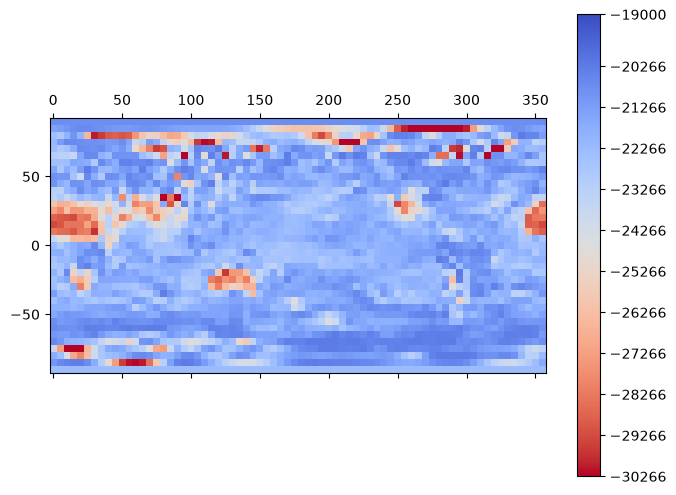

In [15]:
nc.plot(variable='rhum')

**Wrap longitude to −180–180** — this grid spans 0–360 (Pacific-centred). `wrap_longitude` re-frames it to the −180–180 (Greenwich-centred) convention; we wrap the selected variable, then plot the re-centred map.

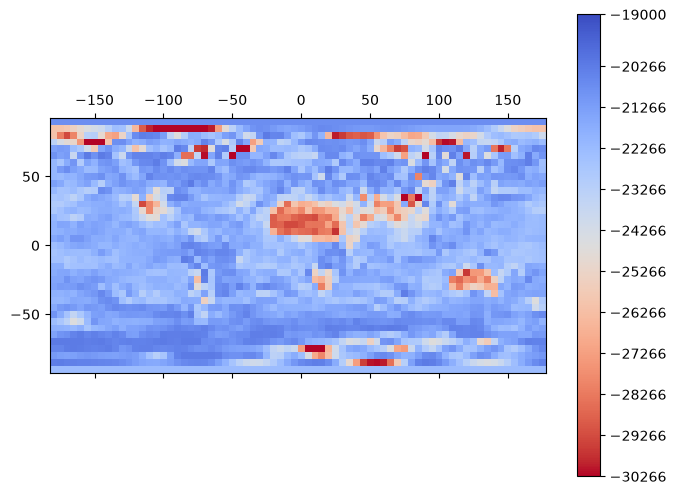

In [16]:
nc.get_variable('rhum').wrap_longitude().plot()

**Retrieve the underlying data**

In [17]:
var = nc.get_variable('rhum')
data = var.read_array()
print('shape:', data.shape)
print('min / mean / max:', float(np.nanmin(data)), float(np.nanmean(data)), float(np.nanmax(data)))

shape: (48, 37, 72)
min / mean / max: -30266.0 -23468.792831894396 -20266.0


**Reduce a dimension** — collapse the time axis to its mean

In [18]:
time_mean = nc.reduce('time', how='mean')
print('dimensions after reducing time:', dict(time_mean.dimension_sizes))

dimensions after reducing time: {'level': 4, 'x': 72, 'y': 37}


**Add a variable** — derive a 2-D field and append it as a new variable

In [19]:
work = Path(tempfile.mkdtemp())
slice2d = data[tuple(0 for _ in range(data.ndim - 2))]
NetCDF.create_from_array(
    arr=slice2d, geo=var.geotransform, epsg=var.epsg or 4326,
    variable_name='rhum_slice0', path=str(work / 'derived.nc'),
)
nc.add_variable(NetCDF.read_file(str(work / 'derived.nc')), 'rhum_slice0')
print('variables after add:', nc.variable_names)

variables after add: ['rhum', 'rhum_slice0']


**Remove a variable**

In [20]:
nc.remove_variable('rhum_slice0')
print('variables after remove:', nc.variable_names)

variables after remove: ['rhum']


**Crop every variable with one polygon** — `crop` clips the whole container in a single call and returns a new `NetCDF`

2026-06-18 02:08:44 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


cropped dimensions: {'level': 4, 'time': 12, 'x': 28, 'y': 15}


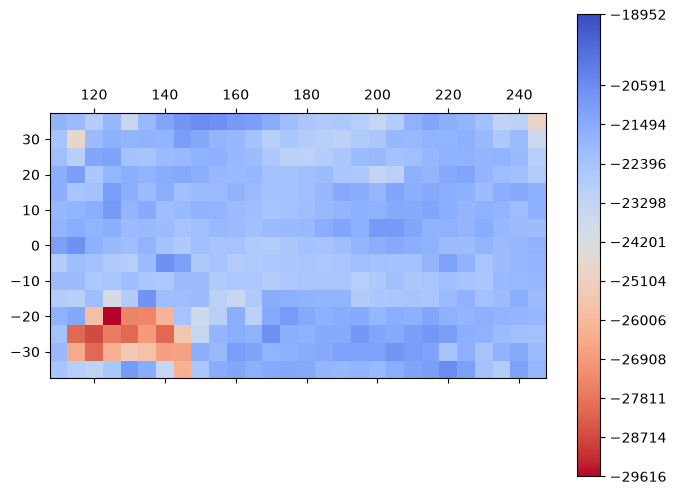

In [21]:
xmin, ymin, xmax, ymax = var.total_bounds
polygon = gpd.GeoDataFrame(
    geometry=[box(xmin + (xmax - xmin) * 0.3, ymin + (ymax - ymin) * 0.3,
                  xmin + (xmax - xmin) * 0.7, ymin + (ymax - ymin) * 0.7)],
    crs=var.epsg or 4326,
)
cropped = nc.crop(FeatureCollection(polygon))
print('cropped dimensions:', dict(cropped.dimension_sizes))
cropped.plot(variable='rhum')

**Save the result to a new NetCDF file**

In [22]:
out = work / 'cropped.nc'
cropped.to_file(str(out))
print('saved cropped container to', out.name, '->', out.exists())

saved cropped container to cropped.nc -> True
